# Predict next-hour cloud cover over Ireland

This is a **new, separate experiment**. We will use six hourly cloud maps to predict the cloud-covered fraction of the following hourly map. The rainfall model and its notebook stay separate.

Run the cells in order. We will verify the mask codes and timestamps before creating targets or training a model.

## Step 1 · Import the libraries

NumPy reads the saved array file. `Path` makes the file location easy to change.

In [1]:
from pathlib import Path
import numpy as np

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## Step 2 · Locate the cloud maps

Run this notebook from the root of the same VS Code project as the rainfall notebook. Change this path only if your cloud file is stored elsewhere.

In [2]:
cloud_file = Path("data/raw/satellite/ireland_clouds_20240101_20250101.npz")

print("Cloud file:", cloud_file.resolve())
print("File found:", cloud_file.is_file())

Cloud file: D:\PhD\radar_cnn_lstm\data\raw\satellite\ireland_clouds_20240101_20250101.npz
File found: True


## Step 3 · Inspect the image sequence

Read the timestamps and cloud-mask grid. Inspect codes in the first 24 maps before deciding which pixels represent cloud or missing data. The complete file should have one image for each hour of leap year 2024.

In [3]:
if not cloud_file.is_file():
    raise FileNotFoundError(
        f"Could not find {cloud_file}. Check the folder path in Step 2."
    )

with np.load(cloud_file) as data:
    print("Arrays in file:", data.files)
    times = data["times"]
    cloud_masks = data["cloud_mask"]

print("Cloud maps shape:", cloud_masks.shape)
print("First time (UTC):", times[0])
print("Last time (UTC):", times[-1])
print("First three time gaps:", np.diff(times[:4]))

values, counts = np.unique(cloud_masks[:24], return_counts=True)
print("Mask values in first 24 maps:", dict(zip(values.tolist(), counts.tolist())))

Arrays in file: ['times', 'cloud_mask', 'cth_km', 'lat', 'lon']
Cloud maps shape: (8784, 90, 120)
First time (UTC): 2024-01-01T00:00:00.000000
Last time (UTC): 2024-12-31T23:00:00.000000
First three time gaps: [3600000000 3600000000 3600000000]
Mask values in first 24 maps: {0: 13424, 1: 33500, 2: 212265, 3: 11}


In [5]:
cloudy_pixels = np.count_nonzero(cloud_masks == 2, axis=(1, 2))
valid_pixels = np.count_nonzero(cloud_masks != 3, axis=(1, 2))

# An hour with no valid pixels has no cloud-cover target.
cloud_cover = np.full(len(cloud_masks), np.nan, dtype=np.float32)
np.divide(cloudy_pixels, valid_pixels, out=cloud_cover, where=valid_pixels > 0)

missing_hours = np.flatnonzero(valid_pixels == 0)
print("Hours with no valid cloud pixels:", len(missing_hours))
print("First missing times:", times[missing_hours[:5]])

input_positions = np.arange(6)
target_position = 6

print("Cloud-cover values:", cloud_cover.shape)
print("First six input times:", times[input_positions])
print("Next-hour target time:", times[target_position])
print("Cloud cover in the last input map:",
      f"{100 * cloud_cover[input_positions[-1]]:.1f}%")
print("Cloud cover in the target map:",
      f"{100 * cloud_cover[target_position]:.1f}%")
print("Minimum and maximum among valid hours:",
      f"{100 * np.nanmin(cloud_cover):.1f}% to {100 * np.nanmax(cloud_cover):.1f}%")

Hours with no valid cloud pixels: 14
First missing times: ['2024-06-27T07:00:00.000000' '2024-07-23T22:00:00.000000'
 '2024-07-23T23:00:00.000000' '2024-07-24T00:00:00.000000'
 '2024-07-24T01:00:00.000000']
Cloud-cover values: (8784,)
First six input times: ['2024-01-01T00:00:00.000000' '2024-01-01T01:00:00.000000'
 '2024-01-01T02:00:00.000000' '2024-01-01T03:00:00.000000'
 '2024-01-01T04:00:00.000000' '2024-01-01T05:00:00.000000']
Next-hour target time: 2024-01-01T06:00:00.000000
Cloud cover in the last input map: 64.1%
Cloud cover in the target map: 63.0%
Minimum and maximum among valid hours: 0.0% to 100.0%


In [6]:
# Each row contains six consecutive input-image positions.
starts = np.arange(len(cloud_masks) - 6)
sequence_positions = starts[:, None] + np.arange(6)
target_positions = starts + 6

# Keep examples only when all six inputs and the target map are valid.
usable = (
    (valid_pixels[sequence_positions] > 0).all(axis=1)
    & (valid_pixels[target_positions] > 0)
)

sequence_positions = sequence_positions[usable]
target_positions = target_positions[usable]
target_cover = cloud_cover[target_positions]

print("Usable examples:", len(target_cover))
print("First input times:", times[sequence_positions[0]])
print("First target time:", times[target_positions[0]])
print("First target cloud cover:", f"{100 * target_cover[0]:.1f}%")

Usable examples: 8740
First input times: ['2024-01-01T00:00:00.000000' '2024-01-01T01:00:00.000000'
 '2024-01-01T02:00:00.000000' '2024-01-01T03:00:00.000000'
 '2024-01-01T04:00:00.000000' '2024-01-01T05:00:00.000000']
First target time: 2024-01-01T06:00:00.000000
First target cloud cover: 63.0%


In [7]:
# Split the 2024 timeline: 70% training, 15% validation, 15% test.
train_end = int(0.70 * len(times))
validation_end = int(0.85 * len(times))

train_rows = np.flatnonzero(target_positions < train_end)

validation_rows = np.flatnonzero(
    (target_positions >= train_end + 6)
    & (target_positions < validation_end)
)

test_rows = np.flatnonzero(
    target_positions >= validation_end + 6
)

for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    print(
        f"{name}: {len(rows)} examples | "
        f"{times[target_positions[rows[0]]]} to "
        f"{times[target_positions[rows[-1]]]}"
    )

Training: 6104 examples | 2024-01-01T06:00:00.000000 to 2024-09-13T03:00:00.000000
Validation: 1312 examples | 2024-09-13T10:00:00.000000 to 2024-11-07T01:00:00.000000
Test: 1312 examples | 2024-11-07T08:00:00.000000 to 2024-12-31T23:00:00.000000


In [8]:
for name, rows in [
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    actual = target_cover[rows]
    persistence = cloud_cover[sequence_positions[rows, -1]]

    mae = np.mean(np.abs(persistence - actual)) * 100
    rmse = np.sqrt(np.mean((persistence - actual) ** 2)) * 100

    print(
        f"{name} persistence | "
        f"MAE: {mae:.2f} percentage points | "
        f"RMSE: {rmse:.2f} percentage points"
    )

Validation persistence | MAE: 3.59 percentage points | RMSE: 6.39 percentage points
Test persistence | MAE: 3.37 percentage points | RMSE: 5.06 percentage points


In [9]:
import torch
from torch.utils.data import Dataset

class CloudCoverDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]

        # Six maps, reduced from 90×120 to 45×60.
        masks = cloud_masks[sequence_positions[row], ::2, ::2]

        cloud = (masks == 2).astype(np.float32)
        valid = (masks != 3).astype(np.float32)

        # Shape: (6 hours, 2 channels, 45 rows, 60 columns)
        images = np.stack([cloud, valid], axis=1)

        # One number between 0 and 1 for the following hour.
        target = np.float32(target_cover[row])

        return torch.from_numpy(images), torch.tensor(target)


train_dataset = CloudCoverDataset(train_rows)

images, target = train_dataset[0]
print("Input images:", images.shape)
print("Next-hour cloud cover:", target)

Input images: torch.Size([6, 2, 45, 60])
Next-hour cloud cover: tensor(0.6302)


In [10]:
from torch.utils.data import DataLoader

validation_dataset = CloudCoverDataset(validation_rows)
test_dataset = CloudCoverDataset(test_rows)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(
    validation_dataset, batch_size=16, shuffle=False
)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

batch_images, batch_targets = next(iter(train_loader))

print("Batch images:", batch_images.shape)
print("Batch targets:", batch_targets.shape)
print("Target range in this batch:",
      batch_targets.min().item(),
      batch_targets.max().item())

Batch images: torch.Size([16, 6, 2, 45, 60])
Batch targets: torch.Size([16])
Target range in this batch: 0.3539544343948364 0.9928703904151917


In [11]:
import torch.nn as nn

class CloudCoverModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Extract features from each hourly map.
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 32),
            nn.ReLU()
        )

        # Learn how those features change across six hours.
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=32,
            batch_first=True
        )

        self.output = nn.Linear(32, 1)

    def forward(self, images):
        batch_size, hours, channels, height, width = images.shape

        # Apply the same CNN to each image.
        images = images.reshape(
            batch_size * hours, channels, height, width
        )
        features = self.cnn(images)
        features = features.reshape(batch_size, hours, 32)

        sequence_output, _ = self.lstm(features)

        # Use the final LSTM state to predict the following hour.
        final_features = sequence_output[:, -1, :]
        cloud_cover = torch.sigmoid(self.output(final_features))

        return cloud_cover.squeeze(1)


model = CloudCoverModel()

with torch.no_grad():
    batch_predictions = model(batch_images)

print("Predictions shape:", batch_predictions.shape)
print("Targets shape:", batch_targets.shape)
print("First predictions:", batch_predictions[:5])

Predictions shape: torch.Size([16])
Targets shape: torch.Size([16])
First predictions: tensor([0.4796, 0.4799, 0.4794, 0.4800, 0.4798])


In [12]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()
optimizer.zero_grad()

predictions = model(batch_images)
loss = loss_function(predictions, batch_targets)

loss.backward()
optimizer.step()

print("Loss after one training batch:", loss.item())

Loss after one training batch: 0.1006108969449997


In [13]:
from pathlib import Path

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)
model_file = models_folder / "best_cloud_cover_model.pt"

best_validation_mae = float("inf")
epochs_without_improvement = 0
history = []

for epoch in range(1, 13):
    # Train
    model.train()
    training_error = 0.0

    for images, targets in train_loader:
        optimizer.zero_grad()

        predictions = model(images)
        loss = loss_function(predictions, targets)

        loss.backward()
        optimizer.step()

        training_error += torch.abs(predictions - targets).sum().item()

    training_mae = 100 * training_error / len(train_dataset)

    # Validate without changing model weights
    model.eval()
    validation_error = 0.0

    with torch.no_grad():
        for images, targets in validation_loader:
            predictions = model(images)
            validation_error += torch.abs(
                predictions - targets
            ).sum().item()

    validation_mae = 100 * validation_error / len(validation_dataset)
    history.append((training_mae, validation_mae))

    print(
        f"Epoch {epoch:02d} | "
        f"Training MAE: {training_mae:.2f} points | "
        f"Validation MAE: {validation_mae:.2f} points",
        flush=True
    )

    if validation_mae < best_validation_mae:
        best_validation_mae = validation_mae
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_file)
        print("  Saved best model", flush=True)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == 4:
            print("Stopped: validation has not improved for 4 epochs.")
            break

print(f"Best validation MAE: {best_validation_mae:.2f} points")
print("Persistence validation MAE: 3.59 points")

Epoch 01 | Training MAE: 8.79 points | Validation MAE: 4.54 points
  Saved best model
Epoch 02 | Training MAE: 3.98 points | Validation MAE: 4.40 points
  Saved best model
Epoch 03 | Training MAE: 3.62 points | Validation MAE: 4.38 points
  Saved best model
Epoch 04 | Training MAE: 3.56 points | Validation MAE: 3.83 points
  Saved best model
Epoch 05 | Training MAE: 3.48 points | Validation MAE: 3.76 points
  Saved best model
Epoch 06 | Training MAE: 3.38 points | Validation MAE: 3.68 points
  Saved best model
Epoch 07 | Training MAE: 3.32 points | Validation MAE: 3.53 points
  Saved best model
Epoch 08 | Training MAE: 3.24 points | Validation MAE: 3.67 points
Epoch 09 | Training MAE: 3.24 points | Validation MAE: 3.89 points
Epoch 10 | Training MAE: 3.20 points | Validation MAE: 3.74 points
Epoch 11 | Training MAE: 3.17 points | Validation MAE: 3.54 points
Stopped: validation has not improved for 4 epochs.
Best validation MAE: 3.53 points
Persistence validation MAE: 3.59 points


In [14]:
# Load the weights saved at the best validation epoch.
model.load_state_dict(
    torch.load(model_file, map_location="cpu", weights_only=True)
)
model.eval()

prediction_batches = []

with torch.no_grad():
    for images, targets in test_loader:
        prediction_batches.append(model(images))

model_predictions = torch.cat(prediction_batches).numpy()

actual = target_cover[test_rows]
persistence_predictions = cloud_cover[
    sequence_positions[test_rows, -1]
]

for name, predictions in [
    ("CNN–LSTM", model_predictions),
    ("Persistence", persistence_predictions),
]:
    mae = np.mean(np.abs(predictions - actual)) * 100
    rmse = np.sqrt(np.mean((predictions - actual) ** 2)) * 100

    print(
        f"{name:12} | "
        f"Test MAE: {mae:.2f} points | "
        f"Test RMSE: {rmse:.2f} points"
    )

CNN–LSTM     | Test MAE: 3.22 points | Test RMSE: 4.51 points
Persistence  | Test MAE: 3.37 points | Test RMSE: 5.06 points


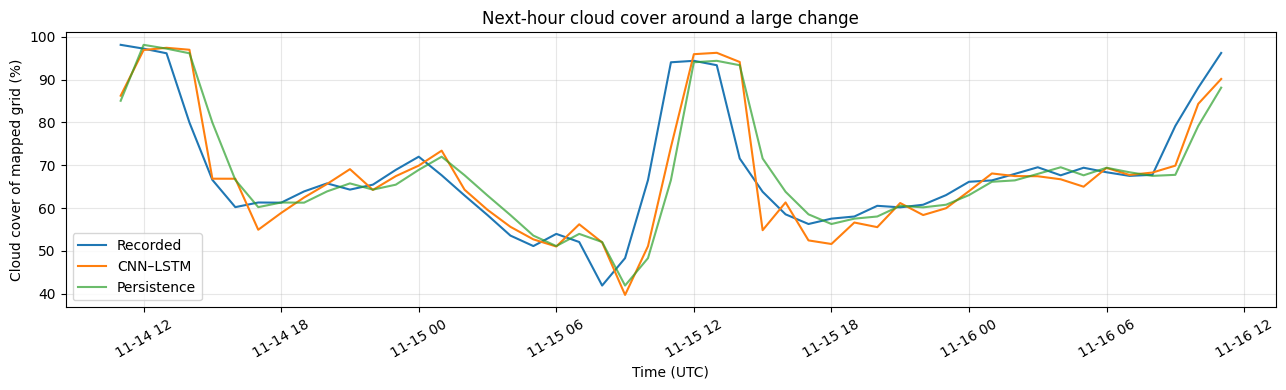

In [15]:
import matplotlib.pyplot as plt

# Find the test hour with the largest change from the previous hour.
largest_change = np.argmax(
    np.abs(actual - persistence_predictions)
)

start = max(0, largest_change - 24)
end = min(len(actual), largest_change + 25)
window = slice(start, end)

plot_times = times[target_positions[test_rows[window]]]

plt.figure(figsize=(13, 4))
plt.plot(plot_times, actual[window] * 100, label="Recorded")
plt.plot(
    plot_times,
    model_predictions[window] * 100,
    label="CNN–LSTM"
)
plt.plot(
    plot_times,
    persistence_predictions[window] * 100,
    label="Persistence",
    alpha=0.7
)

plt.title("Next-hour cloud cover around a large change")
plt.xlabel("Time (UTC)")
plt.ylabel("Cloud cover of mapped grid (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
large_change = np.abs(actual - persistence_predictions) >= 0.10

print("Large-change test hours:", large_change.sum())

for name, predictions in [
    ("CNN–LSTM", model_predictions),
    ("Persistence", persistence_predictions),
]:
    mae = np.mean(
        np.abs(predictions[large_change] - actual[large_change])
    ) * 100
    print(f"{name} MAE during large changes: {mae:.2f} points")

Large-change test hours: 85
CNN–LSTM MAE during large changes: 10.56 points
Persistence MAE during large changes: 14.05 points


In [17]:
other_hours = ~large_change

print("Other test hours:", other_hours.sum())

for name, predictions in [
    ("CNN–LSTM", model_predictions),
    ("Persistence", persistence_predictions),
]:
    mae = np.mean(
        np.abs(predictions[other_hours] - actual[other_hours])
    ) * 100
    print(f"{name} MAE during other hours: {mae:.2f} points")

Other test hours: 1227
CNN–LSTM MAE during other hours: 2.71 points
Persistence MAE during other hours: 2.63 points


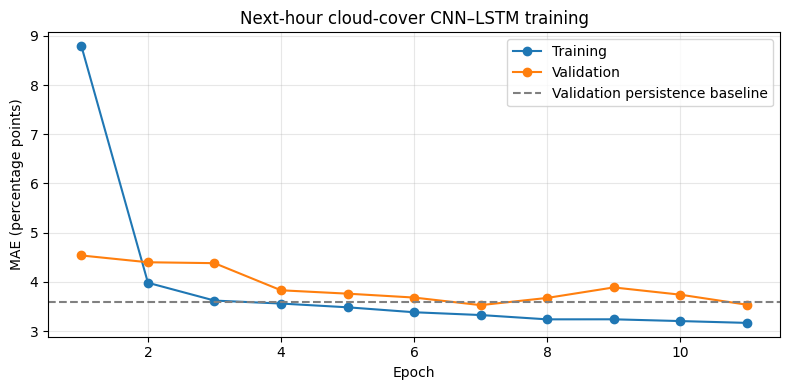

In [18]:
training_mae = [train for train, validation in history]
validation_mae = [validation for train, validation in history]
epoch_numbers = range(1, len(history) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epoch_numbers, training_mae, marker="o", label="Training")
plt.plot(epoch_numbers, validation_mae, marker="o", label="Validation")
plt.axhline(
    3.59,
    color="gray",
    linestyle="--",
    label="Validation persistence baseline"
)

plt.xlabel("Epoch")
plt.ylabel("MAE (percentage points)")
plt.title("Next-hour cloud-cover CNN–LSTM training")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
test_times = times[target_positions[test_rows]]
months = test_times.astype("datetime64[M]")

for month in np.unique(months):
    in_month = months == month

    model_mae = np.mean(
        np.abs(model_predictions[in_month] - actual[in_month])
    ) * 100

    persistence_mae = np.mean(
        np.abs(persistence_predictions[in_month] - actual[in_month])
    ) * 100

    print(
        f"{month} | {in_month.sum()} hours | "
        f"CNN–LSTM MAE: {model_mae:.2f} points | "
        f"Persistence MAE: {persistence_mae:.2f} points"
    )

2024-11 | 568 hours | CNN–LSTM MAE: 3.15 points | Persistence MAE: 3.28 points
2024-12 | 744 hours | CNN–LSTM MAE: 3.28 points | Persistence MAE: 3.44 points


C:\Users\engma\AppData\Local\Temp\ipykernel_30756\1095598824.py:89: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color="#ffffff", label="No data", edgecolor="black"),


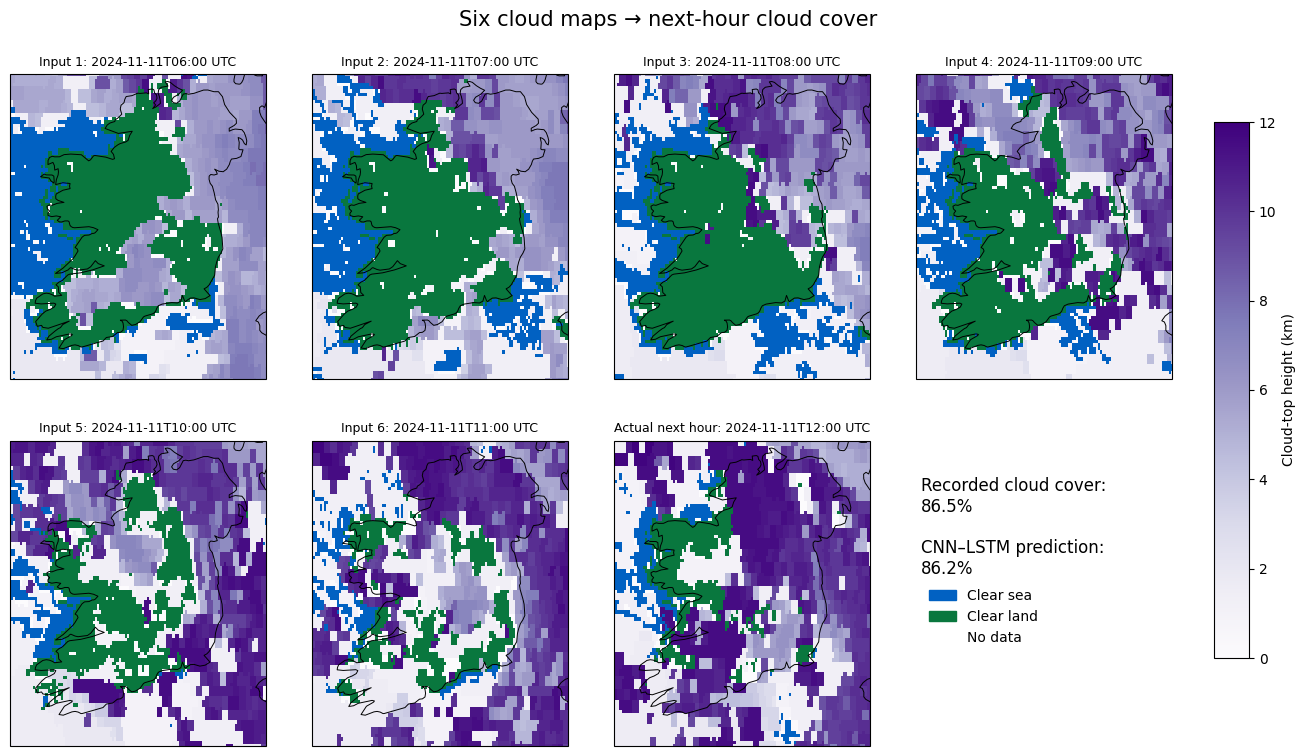

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

example_number = 100
example = test_rows[example_number]
positions_to_show = list(sequence_positions[example]) + [
    target_positions[example]
]

with np.load(cloud_file) as data:
    lat = data["lat"]
    lon = data["lon"]
    heights_to_show = data["cth_km"][positions_to_show]

background = ListedColormap([
    "#0161c2",  # 0: clear sea
    "#09773e",  # 1: clear land
    "#8e63b9",  # 2: cloud
    "#ffffff",  # 3: no data
])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(
    left=0.03, right=0.86, bottom=0.06, top=0.90,
    wspace=0.18, hspace=0.20
)

for panel, position in enumerate(positions_to_show):
    ax = axes.flat[panel]
    mask = cloud_masks[position]
    height = heights_to_show[panel]

    # Blue sea and green land beneath the cloud-height layer.
    ax.pcolormesh(
        lon, lat, mask,
        cmap=background,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    # Show the purple height gradient only where code 2 means cloud.
    cloud_height = np.ma.masked_where(mask != 2, height)
    height_plot = ax.pcolormesh(
        lon, lat, cloud_height,
        cmap="Purples",
        vmin=0,
        vmax=12,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(resolution="50m", color="black", linewidth=0.7)
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )
    ax.set_aspect("auto")

    label = f"Input {panel + 1}" if panel < 6 else "Actual next hour"
    ax.set_title(
        f"{label}: {str(times[position])[:16]} UTC",
        fontsize=9
    )

# The eighth panel shows the numerical prediction.
axes.flat[7].axis("off")
axes.flat[7].text(
    0.02, 0.65,
    f"Recorded cloud cover:\n"
    f"{100 * target_cover[example]:.1f}%\n\n"
    f"CNN–LSTM prediction:\n"
    f"{100 * model_predictions[example_number]:.1f}%",
    transform=axes.flat[7].transAxes,
    fontsize=12
)
axes.flat[7].legend(
    handles=[
        Patch(color="#0161c2", label="Clear sea"),
        Patch(color="#09773e", label="Clear land"),
        Patch(color="#ffffff", label="No data", edgecolor="black"),
    ],
    loc="lower left",
    frameon=False
)

colourbar_area = fig.add_axes([0.89, 0.17, 0.025, 0.67])
fig.colorbar(
    height_plot,
    cax=colourbar_area,
    label="Cloud-top height (km)"
)

fig.suptitle(
    "Six cloud maps → next-hour cloud cover",
    fontsize=15
)
plt.show()

In [24]:
model.eval()

normal_error = 0.0
repeated_error = 0.0

with torch.no_grad():
    for images, targets in validation_loader:
        normal_predictions = model(images)

        # Repeat the last image in all six time positions.
        last_image_only = images[:, -1:, :, :, :].repeat(1, 6, 1, 1, 1)
        repeated_predictions = model(last_image_only)

        normal_error += torch.abs(
            normal_predictions - targets
        ).sum().item()

        repeated_error += torch.abs(
            repeated_predictions - targets
        ).sum().item()

print(
    "Normal six-image validation MAE:",
    f"{100 * normal_error / len(validation_dataset):.2f} points"
)
print(
    "Repeated-last-image validation MAE:",
    f"{100 * repeated_error / len(validation_dataset):.2f} points"
)

Normal six-image validation MAE: 3.53 points
Repeated-last-image validation MAE: 3.82 points


# ** Results**
**Test MAE:** CNN–LSTM 3.22 points; persistence 3.37 points.
**Test RMSE:** CNN–LSTM 4.51 points; persistence 5.06 points.
**Six-image sensitivity check:** 3.53 points versus 3.82 when the last image was repeated.

In [32]:
class CloudMapDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]

        # Six input maps at 45 × 60 pixels.
        input_masks = cloud_masks[
            sequence_positions[row], ::2, ::2
        ]

        cloud = (input_masks == 2).astype(np.float32)
        valid = (input_masks != 3).astype(np.float32)
        images = np.stack([cloud, valid], axis=1)

        # The following hour's map is the target.
        next_mask = cloud_masks[
            target_positions[row], ::2, ::2
        ]
        target_cloud = (next_mask == 2).astype(np.float32)
        target_valid = (next_mask != 3).astype(np.float32)

        return (
            torch.from_numpy(images),
            torch.from_numpy(target_cloud[None, :, :]),
            torch.from_numpy(target_valid[None, :, :]),
        )


map_train_dataset = CloudMapDataset(train_rows)

images, target_map, valid_map = map_train_dataset[0]
print("Six input images:", images.shape)
print("Next-hour cloud map:", target_map.shape)
print("Valid-pixel map:", valid_map.shape)

Six input images: torch.Size([6, 2, 45, 60])
Next-hour cloud map: torch.Size([1, 45, 60])
Valid-pixel map: torch.Size([1, 45, 60])


In [36]:
import torch.nn as nn

class CloudMapModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Extract spatial features from each hourly image.
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Read six hours at each location on the smaller feature map.
        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=16,
            batch_first=True
        )

        # Enlarge the features into a 45 × 60 correction map.
        self.decoder = nn.Sequential(
            nn.Upsample(
                size=(45, 60),
                mode="bilinear",
                align_corners=False
            ),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=1)
        )

    def forward(self, images):
        batch_size, hours, channels, height, width = images.shape

        # Apply the same CNN to each of the six images.
        x = images.reshape(
            batch_size * hours, channels, height, width
        )
        x = self.cnn(x)

        _, features, small_height, small_width = x.shape

        # Make a six-hour sequence for every feature-map location.
        x = x.reshape(
            batch_size, hours, features, small_height, small_width
        )
        x = x.permute(0, 3, 4, 1, 2)
        x = x.reshape(
            batch_size * small_height * small_width,
            hours,
            features
        )

        x, _ = self.lstm(x)

        # Restore the spatial arrangement after the LSTM.
        x = x[:, -1, :]
        x = x.reshape(
            batch_size, small_height, small_width, 16
        )
        x = x.permute(0, 3, 1, 2)

        # Start with the last observed cloud map.
        last_cloud = images[:, -1, 0:1]
        last_map_scores = 4 * last_cloud - 2

        # Learn corrections to that map.
        return last_map_scores + self.decoder(x)


map_model = CloudMapModel()
map_optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)

with torch.no_grad():
    output = map_model(images.unsqueeze(0))

print("Model output:", output.shape)
print("Target map:", target_map.unsqueeze(0).shape)

Model output: torch.Size([1, 1, 45, 60])
Target map: torch.Size([1, 1, 45, 60])


In [34]:
from torch.utils.data import DataLoader

map_validation_dataset = CloudMapDataset(validation_rows)
map_test_dataset = CloudMapDataset(test_rows)

map_train_loader = DataLoader(
    map_train_dataset,
    batch_size=8,
    shuffle=True
)
map_validation_loader = DataLoader(
    map_validation_dataset,
    batch_size=8,
    shuffle=False
)
map_test_loader = DataLoader(
    map_test_dataset,
    batch_size=8,
    shuffle=False
)

batch_images, batch_maps, batch_valid = next(
    iter(map_train_loader)
)

print("Input batch:", batch_images.shape)
print("Target batch:", batch_maps.shape)
print("Valid-pixel batch:", batch_valid.shape)

Input batch: torch.Size([8, 6, 2, 45, 60])
Target batch: torch.Size([8, 1, 45, 60])
Valid-pixel batch: torch.Size([8, 1, 45, 60])


In [35]:
pixel_loss_function = nn.BCEWithLogitsLoss(reduction="none")
map_optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)

map_model.train()
map_optimizer.zero_grad()

scores = map_model(batch_images)
pixel_losses = pixel_loss_function(scores, batch_maps)

# Count loss only where the target pixel is valid.
loss = (pixel_losses * batch_valid).sum() / batch_valid.sum()

loss.backward()
map_optimizer.step()

print("Loss after one image-training batch:", loss.item())
print("Valid target pixels in batch:", int(batch_valid.sum().item()))

Loss after one image-training batch: 0.45002153515815735
Valid target pixels in batch: 21600


In [29]:
correct_pixels = 0
valid_pixel_count = 0
intersection = 0
union = 0

for images, targets, valid in map_validation_loader:
    last_cloud_map = images[:, -1, 0:1] > 0.5
    actual_cloud_map = targets > 0.5
    usable_pixels = valid > 0.5

    correct_pixels += (
        (last_cloud_map == actual_cloud_map) & usable_pixels
    ).sum().item()
    valid_pixel_count += usable_pixels.sum().item()

    intersection += (
        last_cloud_map & actual_cloud_map & usable_pixels
    ).sum().item()
    union += (
        (last_cloud_map | actual_cloud_map) & usable_pixels
    ).sum().item()

print(
    "Last-map validation pixel accuracy:",
    f"{100 * correct_pixels / valid_pixel_count:.1f}%"
)
print(
    "Last-map validation cloud IoU:",
    f"{100 * intersection / union:.1f}%"
)

Last-map validation pixel accuracy: 86.2%
Last-map validation cloud IoU: 82.7%


In [37]:
from pathlib import Path

map_loss_function = nn.BCEWithLogitsLoss(reduction="none")

map_model_file = Path("models/best_cloud_map_model.pt")
map_model_file.parent.mkdir(exist_ok=True)

best_validation_iou = -1.0
epochs_without_improvement = 0
map_history = []

for epoch in range(1, 9):
    # Train the image model.
    map_model.train()
    training_loss_total = 0.0
    training_pixels = 0

    for images, targets, valid in map_train_loader:
        map_optimizer.zero_grad()

        scores = map_model(images)
        pixel_losses = map_loss_function(scores, targets)
        loss = (pixel_losses * valid).sum() / valid.sum()

        loss.backward()
        map_optimizer.step()

        training_loss_total += (pixel_losses * valid).sum().item()
        training_pixels += valid.sum().item()

    training_loss = training_loss_total / training_pixels

    # Check predictions on validation data.
    map_model.eval()
    validation_loss_total = 0.0
    validation_pixels = 0
    intersection = 0
    union = 0

    with torch.no_grad():
        for images, targets, valid in map_validation_loader:
            scores = map_model(images)
            pixel_losses = map_loss_function(scores, targets)

            validation_loss_total += (
                pixel_losses * valid
            ).sum().item()
            validation_pixels += valid.sum().item()

            predicted_cloud = scores >= 0
            actual_cloud = targets > 0.5
            usable = valid > 0.5

            intersection += (
                predicted_cloud & actual_cloud & usable
            ).sum().item()
            union += (
                (predicted_cloud | actual_cloud) & usable
            ).sum().item()

    validation_loss = validation_loss_total / validation_pixels
    validation_iou = 100 * intersection / union

    map_history.append(
        (training_loss, validation_loss, validation_iou)
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Validation cloud IoU: {validation_iou:.1f}%",
        flush=True
    )

    if validation_iou > best_validation_iou:
        best_validation_iou = validation_iou
        epochs_without_improvement = 0
        torch.save(map_model.state_dict(), map_model_file)
        print("  Saved best image model", flush=True)
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement == 3:
            print("Stopped after 3 epochs without IoU improvement.")
            break

print(f"Best model validation cloud IoU: {best_validation_iou:.1f}%")
print("Last-map baseline validation cloud IoU: 82.7%")

Epoch 01 | Training loss: 0.3650 | Validation loss: 0.3499 | Validation cloud IoU: 83.0%
  Saved best image model
Epoch 02 | Training loss: 0.3483 | Validation loss: 0.3457 | Validation cloud IoU: 83.0%
Epoch 03 | Training loss: 0.3419 | Validation loss: 0.3411 | Validation cloud IoU: 83.3%
  Saved best image model
Epoch 04 | Training loss: 0.3375 | Validation loss: 0.3364 | Validation cloud IoU: 83.2%
Epoch 05 | Training loss: 0.3344 | Validation loss: 0.3354 | Validation cloud IoU: 83.3%
  Saved best image model
Epoch 06 | Training loss: 0.3328 | Validation loss: 0.3344 | Validation cloud IoU: 83.4%
  Saved best image model
Epoch 07 | Training loss: 0.3321 | Validation loss: 0.3343 | Validation cloud IoU: 83.3%
Epoch 08 | Training loss: 0.3309 | Validation loss: 0.3324 | Validation cloud IoU: 83.4%
  Saved best image model
Best model validation cloud IoU: 83.4%
Last-map baseline validation cloud IoU: 82.7%


In [38]:
# Load the checkpoint selected by validation cloud IoU.
map_model.load_state_dict(
    torch.load(map_model_file, map_location="cpu", weights_only=True)
)
map_model.eval()

correct_pixels = 0
valid_pixel_count = 0

with torch.no_grad():
    for images, targets, valid in map_validation_loader:
        predicted_cloud = map_model(images) >= 0
        actual_cloud = targets > 0.5
        usable = valid > 0.5

        correct_pixels += (
            (predicted_cloud == actual_cloud) & usable
        ).sum().item()
        valid_pixel_count += usable.sum().item()

print(
    "Image model validation pixel accuracy:",
    f"{100 * correct_pixels / valid_pixel_count:.1f}%"
)
print("Last-map validation pixel accuracy: 86.2%")

Image model validation pixel accuracy: 86.7%
Last-map validation pixel accuracy: 86.2%


In [39]:
results = {
    "CNN–LSTM": {"correct": 0, "valid": 0, "intersection": 0, "union": 0},
    "Last map": {"correct": 0, "valid": 0, "intersection": 0, "union": 0},
}

map_model.eval()

with torch.no_grad():
    for images, targets, valid in map_test_loader:
        actual_cloud = targets > 0.5
        usable = valid > 0.5

        predictions = {
            "CNN–LSTM": map_model(images) >= 0,
            "Last map": images[:, -1, 0:1] > 0.5,
        }

        for name, predicted_cloud in predictions.items():
            results[name]["correct"] += (
                (predicted_cloud == actual_cloud) & usable
            ).sum().item()

            results[name]["valid"] += usable.sum().item()

            results[name]["intersection"] += (
                predicted_cloud & actual_cloud & usable
            ).sum().item()

            results[name]["union"] += (
                (predicted_cloud | actual_cloud) & usable
            ).sum().item()

for name, counts in results.items():
    accuracy = 100 * counts["correct"] / counts["valid"]
    iou = 100 * counts["intersection"] / counts["union"]

    print(
        f"{name:8} | Test pixel accuracy: {accuracy:.1f}% "
        f"| Test cloud IoU: {iou:.1f}%"
    )

CNN–LSTM | Test pixel accuracy: 86.9% | Test cloud IoU: 84.5%
Last map | Test pixel accuracy: 86.3% | Test cloud IoU: 83.8%


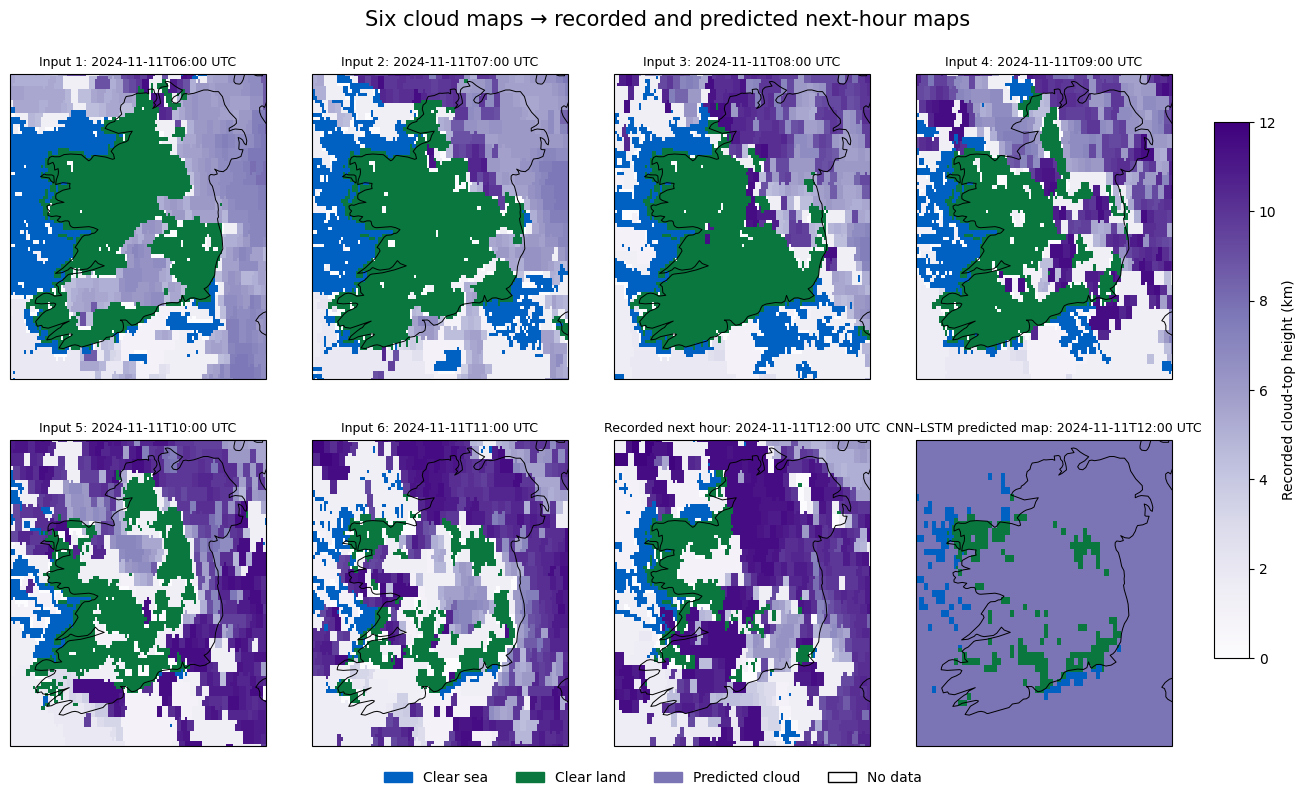

In [45]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

example_number = 100
example = test_rows[example_number]
input_positions = sequence_positions[example]
target_position = target_positions[example]
positions_to_show = list(input_positions) + [target_position]

with np.load(cloud_file) as data:
    lat = data["lat"]
    lon = data["lon"]
    heights_to_show = data["cth_km"][positions_to_show]

# Prepare the same six input channels used to train the map model.
input_masks = cloud_masks[input_positions, ::2, ::2]
cloud = (input_masks == 2).astype(np.float32)
valid = (input_masks != 3).astype(np.float32)
images = torch.from_numpy(np.stack([cloud, valid], axis=1))

# Load the best trained image model and predict the next-hour cloud map.
map_model.load_state_dict(
    torch.load(
        "models/best_cloud_map_model.pt",
        map_location="cpu",
        weights_only=True
    )
)
map_model.cpu()
map_model.eval()

with torch.no_grad():
    scores = map_model(images.unsqueeze(0))
    predicted_cloud = (
        torch.sigmoid(scores)[0, 0].numpy() >= 0.5
    )

# The prediction is 45 × 60; expand it to the original 90 × 120 grid.
predicted_cloud = np.repeat(
    np.repeat(predicted_cloud, 2, axis=0),
    2, axis=1
)

# Blue sea and green land beneath the predicted clouds.
land = np.any(cloud_masks == 1, axis=0)
predicted_mask = np.where(land, 1, 0).astype(np.uint8)
predicted_mask[predicted_cloud] = 2
predicted_mask[cloud_masks[input_positions[-1]] == 3] = 3

background = ListedColormap([
    "#0161c2",                    # clear sea
    "#09773e",                    # clear land
    plt.get_cmap("Purples")(0.65), # predicted cloud
    "#ffffff",                    # no data
])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], background.N)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(
    left=0.03, right=0.86, bottom=0.06, top=0.90,
    wspace=0.18, hspace=0.20
)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = positions_to_show[panel]
        mask = cloud_masks[position]

        ax.pcolormesh(
            lon, lat, mask,
            cmap=background, norm=norm,
            shading="auto",
            transform=ccrs.PlateCarree()
        )

        # Recorded maps retain the original cloud-height colours.
        cloud_height = np.ma.masked_where(
            mask != 2, heights_to_show[panel]
        )
        height_plot = ax.pcolormesh(
            lon, lat, cloud_height,
            cmap="Purples", vmin=0, vmax=12,
            shading="auto",
            transform=ccrs.PlateCarree()
        )

        label = f"Input {panel + 1}" if panel < 6 else "Recorded next hour"
        title_time = times[position]

    else:
        ax.pcolormesh(
            lon, lat, predicted_mask,
            cmap=background, norm=norm,
            shading="auto",
            transform=ccrs.PlateCarree()
        )
        label = "CNN–LSTM predicted map"
        title_time = times[target_position]

    ax.coastlines(resolution="50m", color="black", linewidth=0.7)
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )
    ax.set_aspect("auto")
    ax.set_title(f"{label}: {str(title_time)[:16]} UTC", fontsize=9)

fig.legend(
    handles=[
        Patch(color="#0161c2", label="Clear sea"),
        Patch(color="#09773e", label="Clear land"),
        Patch(color=plt.get_cmap("Purples")(0.65), label="Predicted cloud"),
        Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
    ],
    loc="lower center",
    ncol=4,
    frameon=False
)

colourbar_area = fig.add_axes([0.89, 0.17, 0.025, 0.67])
fig.colorbar(
    height_plot,
    cax=colourbar_area,
    label="Recorded cloud-top height (km)"
)

fig.suptitle(
    "Six cloud maps → recorded and predicted next-hour maps",
    fontsize=15
)
plt.show()